# Customer Churn Prediction

## Phase 3 - Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data1/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Customer Churn Distribution

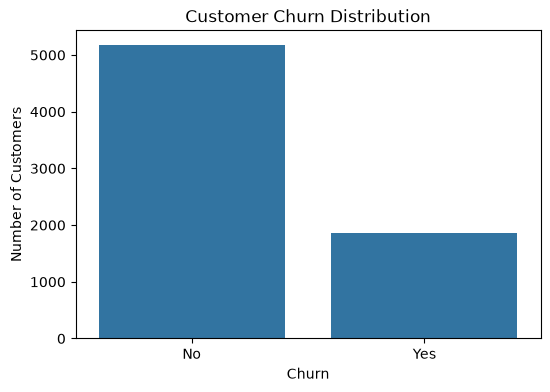

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Most customers did not churn.
- Around 26.5% of customers left the company.
- The dataset is imbalanced because the "No" class has significantly more observations than the "Yes" class.

### Business Insight

The company retains the majority of its customers, but customer churn is still significant. Predicting customers who are likely to churn can help the business take preventive actions and improve customer retention.

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 2. Gender vs Churn

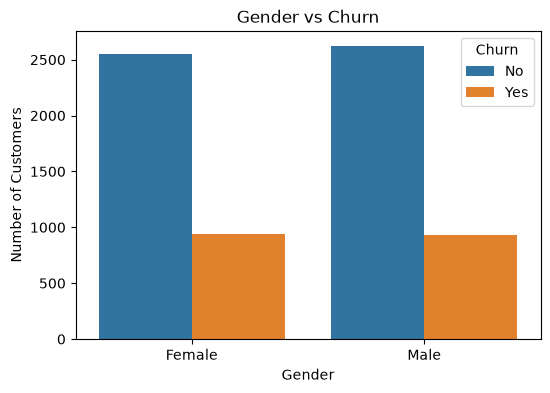

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The number of male and female customers is almost equal.
- Churn occurs in both genders with similar frequency.
- Gender does not appear to have a strong impact on customer churn.

### Business Insight

Customer retention strategies should not be designed based only on gender. Other factors such as contract type, tenure, monthly charges, and internet service are likely to have a greater influence on churn.

In [7]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [8]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### Observation

- The number of male and female customers is almost equal.
- Female customer churn rate is 26.92%.
- Male customer churn rate is 26.16%.
- The difference is only 0.76%, which is very small.

### Business Insight

Gender has very little impact on customer churn. Therefore, customer retention strategies should focus on more influential factors such as contract type, tenure, monthly charges, payment method, and internet service rather than gender.

## 3. Senior Citizen vs Churn

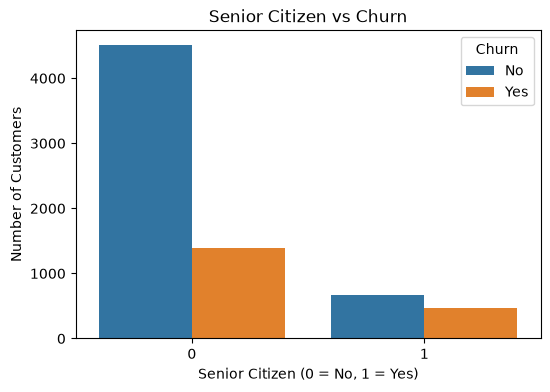

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


In [11]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


## 4. Partner vs Churn

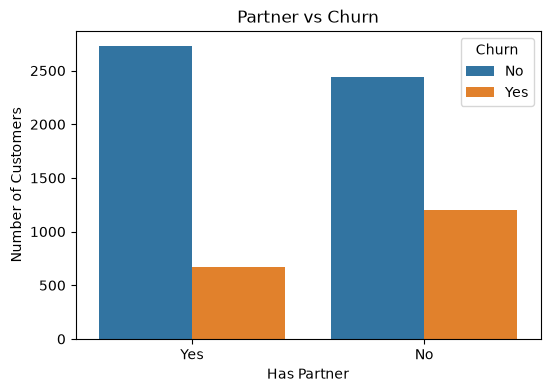

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x="Partner", hue="Churn", data=df)

plt.title("Partner vs Churn")
plt.xlabel("Has Partner")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
pd.crosstab(df["Partner"], df["Churn"])

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


In [14]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


## 5. Dependents vs Churn

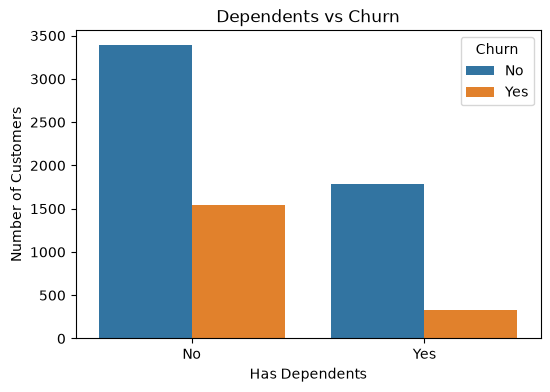

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Dependents", hue="Churn", data=df)

plt.title("Dependents vs Churn")
plt.xlabel("Has Dependents")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
pd.crosstab(df["Dependents"], df["Churn"])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


In [17]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


## 6. Contract Type vs Churn

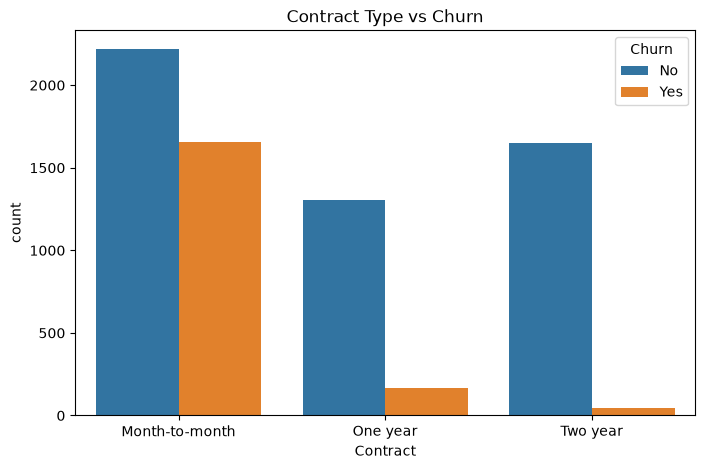

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")

plt.show()

In [19]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [20]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Observation

- Customers with Month-to-Month contracts have the highest churn rate.
- Around 42.71% of Month-to-Month customers churn.
- Customers with a One-Year contract have a much lower churn rate of 11.27%.
- Customers with a Two-Year contract have the lowest churn rate of only 2.83%.

### Business Insight

Contract type is one of the strongest factors affecting customer churn. Customers with longer contracts are much more likely to stay with the company. The company should encourage Month-to-Month customers to switch to long-term contracts through discounts or loyalty benefits.

## 7. Internet Service vs Churn

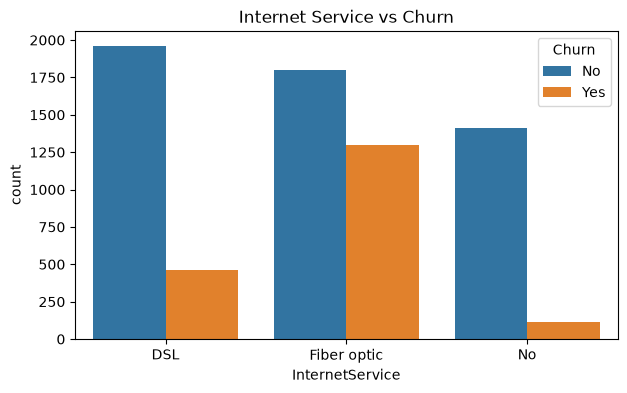

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [21]:
plt.figure(figsize=(7,4))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")

plt.show()

pd.crosstab(df["InternetService"], df["Churn"])

pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

### Observation

- Customers using Fiber Optic internet have the highest churn rate.
- DSL users have a comparatively lower churn rate.
- Customers without internet service have the lowest churn rate.

### Business Insight

Internet service type has a significant impact on customer churn. Fiber Optic customers are more likely to leave the company, which may indicate issues related to pricing, service quality, or customer expectations. The company should investigate Fiber Optic customer complaints and improve service quality to reduce churn.

## 8. PAYMENT VS CHURN

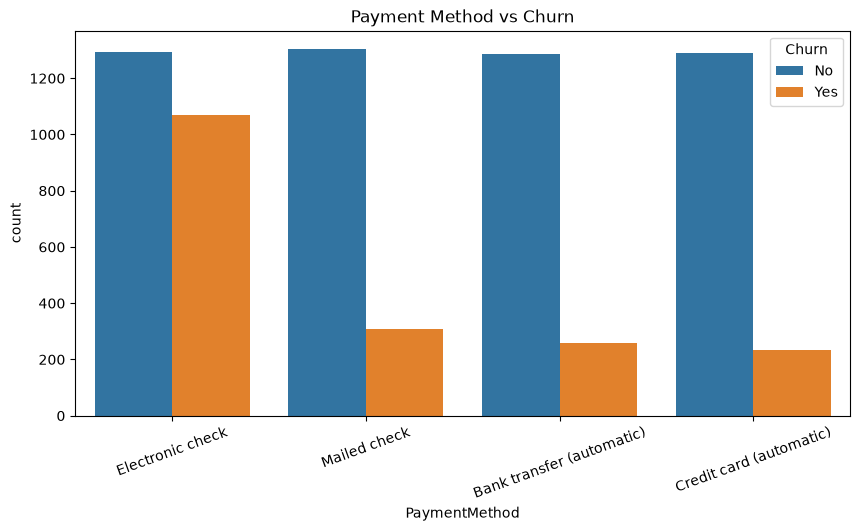

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [22]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

pd.crosstab(df["PaymentMethod"], df["Churn"])

pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

### Observation

- Customers using Electronic Check have the highest churn rate.
- Customers using automatic payment methods such as Bank Transfer and Credit Card have lower churn rates.
- Mailed Check customers also show relatively lower churn compared to Electronic Check users.

### Business Insight

Payment method influences customer retention. Customers using Electronic Check are more likely to churn, while customers using automatic payment methods tend to stay longer. Encouraging customers to switch to automatic payment methods may improve retention.

## 9. MONTHLY CHARGE DISTRIBUTION

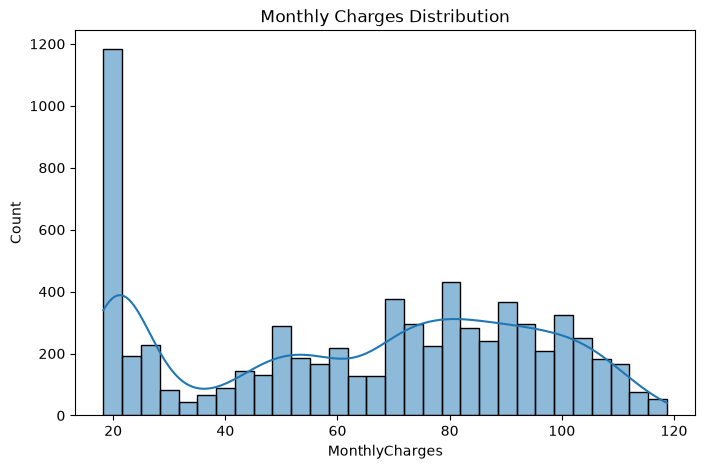

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

### Observation

- Customers using Electronic Check have the highest churn rate.
- Customers using automatic payment methods such as Bank Transfer and Credit Card have lower churn rates.
- Mailed Check customers also show relatively lower churn compared to Electronic Check users.

### Business Insight

Payment method influences customer retention. Customers using Electronic Check are more likely to churn, while customers using automatic payment methods tend to stay longer. Encouraging customers to switch to automatic payment methods may improve retention.

## 10. Tenure Distribution

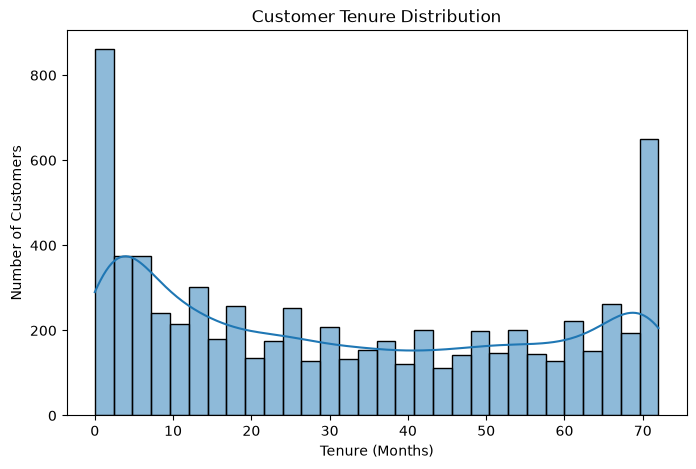

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
plt.figure(figsize=(6,4))

sns.heatmap(df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

ValueError: could not convert string to float: ' '

<Figure size 600x400 with 0 Axes>

In [26]:
df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [27]:
df["TotalCharges"].head(15)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
Name: TotalCharges, dtype: str

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [29]:
df["TotalCharges"].dtype

dtype('float64')

In [30]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [31]:
df = df.dropna()

In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

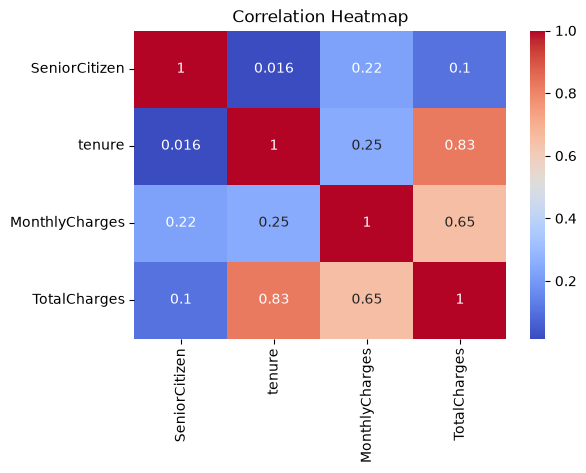

In [33]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Total Charges have a strong positive correlation with customer tenure.
- Monthly Charges have a moderate positive correlation with Total Charges.
- Senior Citizen has a very weak correlation with the numerical features.
- There is no strong multicollinearity among the selected numerical variables.

### Business Insight

Customers with longer tenure naturally generate higher total revenue for the company. Improving customer retention can significantly increase customer lifetime value and overall business revenue.